In [1]:
import pandas
import sqlite3
import matplotlib.pyplot as plt

In [2]:
con = sqlite3.connect('bishop.db')
df = pandas.read_sql_query("SELECT * FROM main", con, parse_dates=['timestamp'])
df

,timestamp,power_pv,power_fridge,power_dishwasher,temperature
0,2026-04-13 18:47:52.534732-07:00,0.000,NaN,NaN,NaN
1,2026-04-13 18:48:17.443186-07:00,0.000,NaN,NaN,NaN
2,2026-04-13 18:55:21.990712-07:00,1.903,NaN,NaN,NaN
3,2026-04-13 18:55:26.003345-07:00,1.903,NaN,NaN,NaN
4,2026-04-13 18:55:33.333406-07:00,0.000,NaN,NaN,NaN
...,...,...,...,...,...
15260,2026-05-17 09:07:01.316032-07:00,7.211,0.0,0.0,19.687
15261,2026-05-17 09:12:05.159239-07:00,7.238,0.0,0.0,19.750
15262,2026-05-17 09:17:12.189060-07:00,9.279,0.0,0.0,19.750
15263,2026-05-17 09:22:21.949708-07:00,7.264,0.0,0.0,19.812


In [29]:
df_resampled

,power_pv,power_fridge,power_dishwasher,temperature,quarter_hour
timestamp,,,,,
2026-04-13 18:45:00-07:00,0.831455,NaN,NaN,NaN,3
2026-04-13 19:00:00-07:00,0.000000,NaN,NaN,NaN,0
2026-04-13 19:15:00-07:00,0.000000,NaN,NaN,NaN,1
2026-04-13 19:30:00-07:00,0.000000,NaN,NaN,NaN,2
2026-04-13 19:45:00-07:00,0.000000,NaN,NaN,NaN,3
...,...,...,...,...,...
2026-05-17 08:15:00-07:00,4.353667,0.0,0.0,19.270667,1
2026-05-17 08:30:00-07:00,7.399667,0.0,0.0,19.416333,2
2026-05-17 08:45:00-07:00,5.976000,0.0,0.0,19.666667,3


<Axes: xlabel='timestamp'>

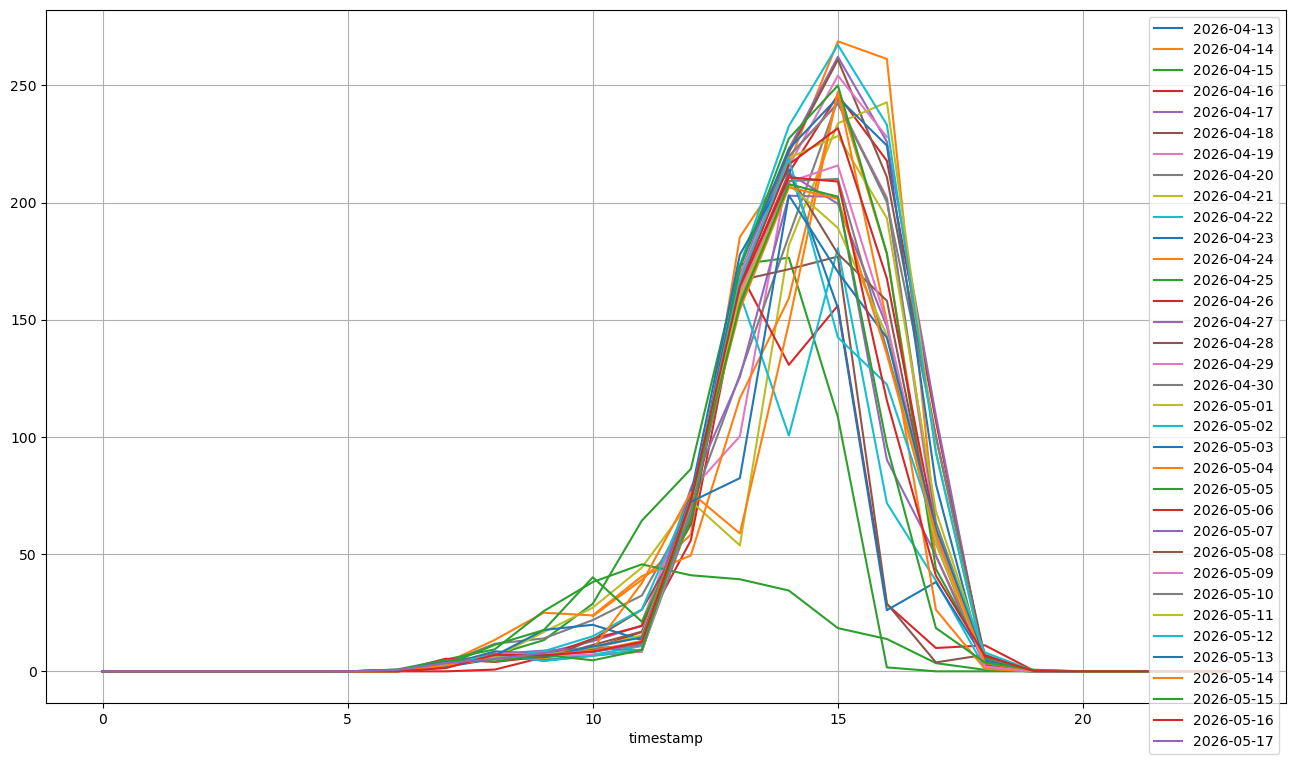

In [ ]:
fig, ax = plt.subplots(figsize=(16, 9))

# Resample to 15 minutes and take the mean
df_resampled = df.set_index('timestamp').resample('15min').mean()
df_resampled['15minoftheday'] = df_resampled.index.hour + df_resampled.index.minute / 60.0

# pivot to daily series
df_pivot = df_resampled.pivot_table(columns=df_resampled.index.date, index=df_resampled.index.hour, values='power_pv')
df_pivot.plot(ax=ax, grid='on')


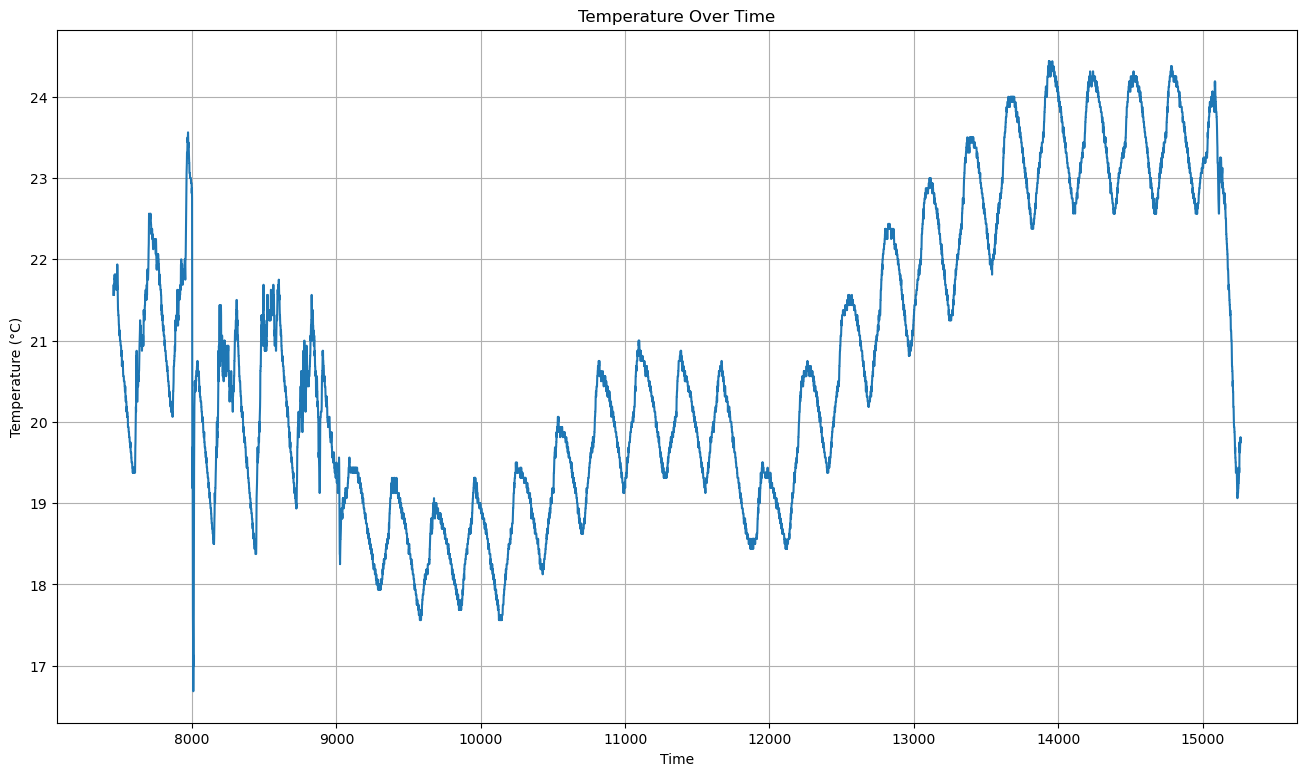

In [7]:
fig, ax = plt.subplots(figsize=(16, 9))
df['temperature'].plot(grid='on', ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Over Time')
plt.show()
